<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW5/Homework5_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1

##Part 1:

###Prepare & Visualize Dataset

The dataset I chose to use was this [Pokemon Image Dataset](https://www.kaggle.com/datasets/vishalsubbiah/pokemon-images-and-types), which is under the [Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/). This dataset was created by Vishal Subbiah and has the following acknowledgements:
data scrapped from https://pokemondb.net/pokedex/national; cover image from https://www.hjackets.com/blog/pikachu-costume-for-kids-and-adult/.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
os.chdir("/content/drive/MyDrive/ColabData/hw5")

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load in pokemon data (names and primary type)
df = pd.read_csv("pokemon.csv")
df = df[['Name', 'Type1']]
df['Name'] = df['Name'].str.lower()

# proof that we have no null values
print(df.info())

# train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Type1'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    809 non-null    object
 1   Type1   809 non-null    object
dtypes: object(2)
memory usage: 12.8+ KB
None


In [11]:
# look at image sizes to see if they're consistent
from PIL import Image
sizes = set()
for root, dirs, files in os.walk("images"):
  for file in files:
    img = Image.open(os.path.join(root, file))
    sizes.add(img.size)

print(sizes)

{(120, 120)}


As we can see, all images are the same size so they don't need resizing.

In [12]:
import shutil

def load_data(df, split):
  for _, row in df.iterrows():
    name = row['Name']
    primary_type = row['Type1']

    # get pokemon image, store it in a train/test folder (split)
    # grouped by its primary type
    src = os.path.join("images", f"{name}.png")
    dst = os.path.join("data", split, primary_type, f"{name}.png")
    os.makedirs(os.path.dirname(dst), exist_ok=True)

    if os.path.exists(src):
      shutil.copy(src, dst)

load_data(train_df, "train")
load_data(test_df, "test")

Let us do some dataset visualization. Here we can see that for various pokemon types, we have images of pokemon that are that type. For example, under the water type, we have Magikarp.

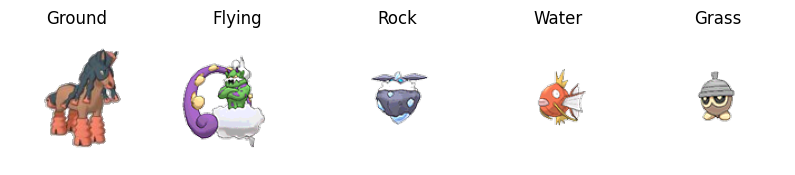

In [13]:
import matplotlib.pyplot as plt

def show_samples(n=5):
  types = os.listdir("data/train")
  plt.figure(figsize=(10,10))

  for i, t in enumerate(types[:n]):
    img_pth = os.path.join("data/train", t, os.listdir(os.path.join("data/train", t))[0])
    img = Image.open(img_pth)

    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.title(t)
    plt.axis("off")

  plt.show()

show_samples()

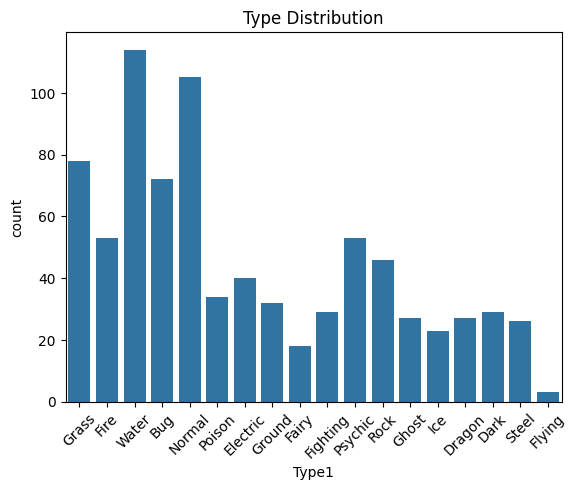

In [14]:
# look at type distribution
import seaborn as sns

sns.countplot(data=df, x="Type1")
plt.xticks(rotation=45)
plt.title("Type Distribution")
plt.show()

As we can see, there are very few flying types. This is most likely because flying is listed as a secondary type for most pokemon, rather than their primary type.

In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = datasets.ImageFolder("data/train", transform=transform)
test_ds = datasets.ImageFolder("data/test", transform=transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

###Create CNN

In [16]:
import torch.nn as nn

# small CNN
# conv base follows a 3 block pattern
class CNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.conv = nn.Sequential(
        # block 1
        nn.Conv2d(3, 16, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        # block 2
        nn.Conv2d(16, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        # block 3
        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.fc = nn.Sequential(
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(64, num_classes)
    )

  def forward(self, x):
    x = self.conv(x)
    x = self.fc(x)
    return x

I chose the following architecture for my convolutional base:

3 blocks, in which the each block does `conv -> relu -> maxpool`.

I chose this pattern because I wanted to avoid anything overly complex for a fairly simple task (since that would lead to overfitting). Between the fact that my dataset has only ~800 images and the fact that Pokemon have bright colors and clear outlines, so a very complex model shouldn't be needed to classify them. The model starts out simpler in the earlier blocks to let the early layers learn simple patterns (colors, edges, etc), and then gets more complex for the deeper layers to learn things like body parts or overall shape.

Each block only has one conv layer to learn patterns (starting simple with learning colors and edges, and the deeper blocks can focus on more complex ideas like overall shape). More conv layers would probably lead to overfitting. Then, we shrink the images using maxpool (allowing the model to better generalize and ignore noise).

In [38]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(train_ds.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [36]:
def train_model(model, train_loader, test_loader, epochs=15):
    for epoch in range(epochs):
        # train
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        train_loss /= len(train_loader)

        # evaluate
        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_loss += loss.item()

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        test_loss /= len(test_loader)
        test_acc = correct / len(test_loader.dataset)

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
        print()

In [39]:
train_model(model, train_dl, test_dl)

Epoch 1
Train Loss: 2.7744
Test Loss: 3.2143, Test Acc: 0.0432

Epoch 2
Train Loss: 2.7142
Test Loss: 3.1846, Test Acc: 0.0432

Epoch 3
Train Loss: 2.7010
Test Loss: 3.1696, Test Acc: 0.0000

Epoch 4
Train Loss: 2.6835
Test Loss: 3.1209, Test Acc: 0.0123

Epoch 5
Train Loss: 2.6847
Test Loss: 3.2365, Test Acc: 0.0000

Epoch 6
Train Loss: 2.6170
Test Loss: 3.2330, Test Acc: 0.0432

Epoch 7
Train Loss: 2.5918
Test Loss: 3.1346, Test Acc: 0.0556

Epoch 8
Train Loss: 2.5606
Test Loss: 3.1148, Test Acc: 0.0617

Epoch 9
Train Loss: 2.5229
Test Loss: 3.2018, Test Acc: 0.0432

Epoch 10
Train Loss: 2.4996
Test Loss: 3.1647, Test Acc: 0.0926

Epoch 11
Train Loss: 2.5008
Test Loss: 3.2270, Test Acc: 0.0679

Epoch 12
Train Loss: 2.5123
Test Loss: 3.1106, Test Acc: 0.0864

Epoch 13
Train Loss: 2.5077
Test Loss: 3.2348, Test Acc: 0.0802

Epoch 14
Train Loss: 2.4825
Test Loss: 3.1293, Test Acc: 0.0679

Epoch 15
Train Loss: 2.4680
Test Loss: 3.2913, Test Acc: 0.0741



###Evaluation and Metrics

In the above run, we saw the best performance at epoch 9, which had metrics:   
Train Loss: 2.4996  
Test Loss: 3.1647, Test Acc: 0.0926

Honestly, this model is absolutely terrible, despite me messing around with parameters as much as possible to improve it. The accuracy is pretty bad (with 18 pokemon types, random guessing has a 1/18 chance of being right, which is around 5%--our model does better than this, but not by much). The loss is also quite high, which indicates some overfitting, but adding any dropout or less epochs led to the model performing worse and I wanted it to at least be better than random guessing.

In the end, I think the model just couldn't get around the incredibly small dataset it was provided to train on. It just didn't have enough data to learn any meaningful patterns.

##Part 2:

Now, we will use resnet to perform the same classification task.

In [28]:
from torchvision.models import resnet18
import torch.nn as nn

model_rs = resnet18(weights='DEFAULT')
model_rs.fc = nn.Linear(model_rs.fc.in_features, len(train_ds.classes))
model_rs = model_rs.to(device)

In [29]:
optimizer = optim.Adam(model_rs.parameters(), lr=1e-4)
train_model(model_rs, train_dl, test_dl)

Epoch 1
Train Loss: 2.7971
Test Loss: 4.4953, Test Acc: 0.0432

Epoch 2
Train Loss: 2.3637
Test Loss: 3.6538, Test Acc: 0.0556

Epoch 3
Train Loss: 2.0831
Test Loss: 4.1062, Test Acc: 0.0432

Epoch 4
Train Loss: 1.9007
Test Loss: 3.7916, Test Acc: 0.0741

Epoch 5
Train Loss: 1.6941
Test Loss: 3.9190, Test Acc: 0.1481

Epoch 6
Train Loss: 1.6250
Test Loss: 4.3643, Test Acc: 0.0802

Epoch 7
Train Loss: 1.5279
Test Loss: 4.4575, Test Acc: 0.0864

Epoch 8
Train Loss: 1.2829
Test Loss: 5.4142, Test Acc: 0.0988

Epoch 9
Train Loss: 1.1548
Test Loss: 5.7383, Test Acc: 0.1111

Epoch 10
Train Loss: 1.2026
Test Loss: 5.0875, Test Acc: 0.1173

Epoch 11
Train Loss: 0.9804
Test Loss: 4.5438, Test Acc: 0.1358

Epoch 12
Train Loss: 0.9481
Test Loss: 6.6504, Test Acc: 0.0741

Epoch 13
Train Loss: 0.7315
Test Loss: 5.8363, Test Acc: 0.1173

Epoch 14
Train Loss: 0.5736
Test Loss: 6.1962, Test Acc: 0.0741

Epoch 15
Train Loss: 0.5097
Test Loss: 6.8008, Test Acc: 0.0617



I was expecting that resnet would have better performance since it is a larger model pretrained on a lot more images (whereas my CNN only ever got to train on the 800 pokemon images). However, while it did show slightly better accuracy, it came at the cost of very clearly overfitting on the data. The best accuracy was seen at epoch 13, where Train Loss: 0.9804, Test Loss: 4.5438, and Test Acc: 0.1358. This is a better accuracy (though still not great) but the test loss was very high. Even on the second epoch, the test loss was already higher than the from-scratch model's loss ever reached.

Resnet is a more complex model than my very small CNN. As a result, training on a very small dataset it will overfit very quickly, which is what we saw here. I was hoping that I would get to see better accuracy in the very least, but it seems that the flaw with my dataset not having enough images still stands.

##Part 3:

We will now use data augmentation to diversify the dataset and see how it affects our CNN model's performance.

In [40]:
# apply random flips and rotations
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = datasets.ImageFolder("data/train", transform=train_transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

In [41]:
model2 = CNN(num_classes=len(train_ds.classes))
model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)

In [42]:
train_model(model2, train_dl, test_dl)

Epoch 1
Train Loss: 2.7987
Test Loss: 3.1798, Test Acc: 0.0000

Epoch 2
Train Loss: 2.7236
Test Loss: 3.1470, Test Acc: 0.0000

Epoch 3
Train Loss: 2.7051
Test Loss: 3.2075, Test Acc: 0.0000

Epoch 4
Train Loss: 2.7072
Test Loss: 3.1177, Test Acc: 0.0062

Epoch 5
Train Loss: 2.7011
Test Loss: 3.1971, Test Acc: 0.0062

Epoch 6
Train Loss: 2.6639
Test Loss: 3.2640, Test Acc: 0.0062

Epoch 7
Train Loss: 2.6247
Test Loss: 3.2279, Test Acc: 0.0062

Epoch 8
Train Loss: 2.5747
Test Loss: 3.1410, Test Acc: 0.0370

Epoch 9
Train Loss: 2.5378
Test Loss: 3.1810, Test Acc: 0.0494

Epoch 10
Train Loss: 2.5294
Test Loss: 3.1594, Test Acc: 0.0432

Epoch 11
Train Loss: 2.5261
Test Loss: 3.1968, Test Acc: 0.0432

Epoch 12
Train Loss: 2.5125
Test Loss: 3.3431, Test Acc: 0.0556

Epoch 13
Train Loss: 2.4837
Test Loss: 3.2146, Test Acc: 0.0864

Epoch 14
Train Loss: 2.4804
Test Loss: 3.2174, Test Acc: 0.0679

Epoch 15
Train Loss: 2.4748
Test Loss: 3.2499, Test Acc: 0.0741



There wasn't too much of a difference in result. The accuracy didn't go as high, but I think that could be chalked up to random chance more than anything. The loss didn't change much from the baseline loss either.

These results were pretty uninteresting. I think the dataset was so small that images being flipped or rotated simply didn't have much of an impact on the model's learning. I decided to try this with the resnet model, which was greatly overfitting, and see if it would have an impact on that model's performance as well:

In [44]:
model_rs2 = resnet18(weights='DEFAULT')
model_rs2.fc = nn.Linear(model_rs2.fc.in_features, len(train_ds.classes))
model_rs2 = model_rs2.to(device)
optimizer = optim.Adam(model_rs2.parameters(), lr=1e-4)
train_model(model_rs2, train_dl, test_dl)

Epoch 1
Train Loss: 2.8127
Test Loss: 3.1643, Test Acc: 0.0617

Epoch 2
Train Loss: 1.9732
Test Loss: 3.2405, Test Acc: 0.0679

Epoch 3
Train Loss: 1.5017
Test Loss: 3.2064, Test Acc: 0.1296

Epoch 4
Train Loss: 1.2047
Test Loss: 3.4344, Test Acc: 0.0864

Epoch 5
Train Loss: 0.9142
Test Loss: 3.4958, Test Acc: 0.1173

Epoch 6
Train Loss: 0.7205
Test Loss: 3.6790, Test Acc: 0.0802

Epoch 7
Train Loss: 0.5622
Test Loss: 3.8015, Test Acc: 0.0864

Epoch 8
Train Loss: 0.3718
Test Loss: 3.7285, Test Acc: 0.1111

Epoch 9
Train Loss: 0.3084
Test Loss: 3.9064, Test Acc: 0.0988

Epoch 10
Train Loss: 0.2621
Test Loss: 3.8797, Test Acc: 0.1296

Epoch 11
Train Loss: 0.2051
Test Loss: 4.1873, Test Acc: 0.1173

Epoch 12
Train Loss: 0.2077
Test Loss: 4.2612, Test Acc: 0.1173

Epoch 13
Train Loss: 0.1460
Test Loss: 4.2539, Test Acc: 0.1049

Epoch 14
Train Loss: 0.1180
Test Loss: 4.2288, Test Acc: 0.1173

Epoch 15
Train Loss: 0.1072
Test Loss: 4.3377, Test Acc: 0.1235



The impacts on the resnet model, which was severely overfitting before, are much more apparent. The test loss is better, showing that there was less overfitting. The model was able to better generalize thanks to the data augmentation. The accuracy was not impacted much this time either, though again it was slightly lower than the model trained without data augmentation.

Overall, it appears that in exchange for a slight dip in accuracy, the model is able to avoid overfitting nearly as much when we apply transformations to the training data. This really shows the importance in good data preprocessing--a small tweak like image rotation can lead to significant change in model performance!